In [ ]:
import pandas as pd
import os

print("1. Скачиваем все файлы данных с вашего GitHub...")
base_url = "https://raw.githubusercontent.com/Anna-Vashurkina/LAB-1/main/data/"
files = [
    'sightings.csv',
    'crime_incidents.csv',
    'locations.csv',
    'weather.csv',
    'witnesses_public.csv',
    'forecast_sequences.csv'
]

for file in files:
    url = base_url + file
    print(f"Скачиваем {file}...")
    try:
        df_temp = pd.read_csv(url)
        df_temp.to_csv(file, index=False)
    except Exception as e:
        print(f"Не удалось скачать {file}: {e}")

print("\n2. Загружаем таблицы и приводим время к единому формату...")
sightings = pd.read_csv('sightings.csv')
crimes = pd.read_csv('crime_incidents.csv')
locations = pd.read_csv('locations.csv')
weather = pd.read_csv('weather.csv')
witnesses = pd.read_csv('witnesses_public.csv')

# Корректное преобразование даты и часа для слияния с погодой
sightings['timestamp'] = pd.to_datetime(sightings['timestamp'])
sightings['date'] = sightings['timestamp'].dt.strftime('%Y-%m-%d')
sightings['hour'] = sightings['timestamp'].dt.hour.astype(int)

weather['date'] = pd.to_datetime(weather['date']).dt.strftime('%Y-%m-%d')
weather['hour'] = weather['hour'].astype(int)

print("3. Выполняем многотабличное слияние...")
# Добавляем свидетелей
if 'sighting_id' in witnesses.columns:
    merged_df = sightings.merge(witnesses, on='sighting_id', how='left', suffixes=('', '_witness'))
else:
    merged_df = sightings

# Добавляем инциденты
merged_df = merged_df.merge(crimes, left_on='nearest_crime_id', right_on='crime_id', how='left', suffixes=('', '_crime'))

# Добавляем локации
merged_df = merged_df.merge(locations, on='district', how='left', suffixes=('', '_loc'))

# Добавляем погоду
merged_df = merged_df.merge(weather, on=['date', 'hour'], how='left', suffixes=('', '_weather'))

print("4. Сохраняем результат в full_dataset.csv...")
merged_df.to_csv('full_dataset.csv', index=False)

print(f"\nУспешно! Итоговый размер объединенного датасета: {merged_df.shape[0]} строк, {merged_df.shape[1]} колонок.")

1. Скачиваем все файлы данных с вашего GitHub...
Скачиваем sightings.csv...
Скачиваем crime_incidents.csv...
Скачиваем locations.csv...
Скачиваем weather.csv...
Скачиваем witnesses_public.csv...
Скачиваем forecast_sequences.csv...

2. Загружаем таблицы и приводим время к единому формату...
3. Выполняем многотабличное слияние...
4. Сохраняем результат в full_dataset.csv...

Успешно! Итоговый размер объединенного датасета: 86631 строк, 70 колонок.


# 1. Постановка задачи (Business Understanding)

### 1.1. Описание данных
Представленный датасет представляет собой систему мониторинга городской активности и происшествий, связанных с человеком-пауком. Данные содержат информацию о наблюдениях, инцидентах, погодных условиях, локациях и показаниях свидетелей.

### 1.2. Условный заказчик
Заказчиком выступает аналитический отдел городской администрации, заинтересованный в оценке безопасности районов и анализе обстановки.

### 1.3. Задачи интеллектуального анализа данных
1. Описательная аналитика: поиск закономерностей между погодными условиями и частотой инцидентов.
2. Поиск аномалий: выявление резких всплесков активности в районах города.

# 2. Паспорт датасета (Data Understanding)
Ниже выполнены загрузка объединенных данных, проверка их размеров и формирование детального паспорта признаков.

In [ ]:
import pandas as pd
import numpy as np

# 1. Загрузка данных
df = pd.read_csv('full_dataset.csv')

# 2. Исправление типов данных
# Мы используем .apply(pd.to_numeric), чтобы превратить текст в числа, а ошибки заменить на NaN
cols_to_fix = ['hour', 'witness_count', 'temperature_c', 'precipitation_mm']

for col in cols_to_fix:
    if col in df.columns:
        # Превращаем в числа, все нечисловые значения становятся NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')
        # Заполняем NaN нулями
        df[col] = df[col].fillna(0)
        # Теперь безопасно приводим к целому типу
        df[col] = df[col].astype('int64')

# Приведение временных меток
if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce').dt.date

# 3. Словарь с гипотезами
# 3. Словарь с гипотезами о смысле признаков (Feature Dictionary)
feature_meanings = {
    'sighting_id': 'Уникальный идентификатор наблюдения',
    'split': 'Признак разбиения данных (train/test/val)',
    'timestamp': 'Дата и время события',
    'date': 'Дата события',
    'hour': 'Час события (0-23)',
    'district': 'Район города',
    'latitude': 'Широта',
    'longitude': 'Долгота',
    'report_type': 'Тип отчета',
    'witness_count': 'Количество свидетелей',
    'tracker_confidence': 'Уверенность трекера',
    'photo_evidence': 'Наличие фото',
    'video_evidence': 'Наличие видео',
    'nearest_crime_id': 'ID ближайшего преступления',
    'crime_id': 'ID преступления',
    'crime_type': 'Тип преступления',
    'weather_condition': 'Погода',
    'temperature_c': 'Температура (C)',
    'precipitation_mm': 'Осадки (мм)',
    'visibility_m': 'Видимость (м)',
    'verification_status': 'Статус верификации',
    'is_verified': 'Бинарный признак',
    'wind_kmh': 'Скорость ветра (км/ч)',
    'cloud_cover': 'Облачность (%)',
    'condition': 'Погодное условие (дубликат weather_condition)',
    'visibility_m_weather': 'Видимость из таблицы погоды (дубликат)',
    'temperature_c_weather': 'Температура из таблицы погоды (дубликат)',
    'precipitation_mm_weather': 'Осадки из таблицы погоды (дубликат)',
    'district_loc': 'Район из таблицы локаций (дубликат)',
    'borough': 'Боро (административный округ)',
    'h3_cell': 'Идентификатор гео-ячейки H3',
    'crime_description': 'Описание преступления',
    'crime_severity': 'Серьезность преступления',
    'witness_age': 'Возраст свидетеля',
    'witness_gender': 'Пол свидетеля',
    'witness_statement': 'Показания свидетеля'
}

# 4. Формирование паспорта
passport_data = []
for col in df.columns:
    dtype = str(df[col].dtype)
    null_count = df[col].isnull().sum()
    null_pct = (null_count / len(df)) * 100
    meaning = feature_meanings.get(col, 'Нет описания')

    passport_data.append({
        'Признак': col,
        'Тип (pandas)': dtype,
        'Предположительный смысл': meaning,
        'Пропуски (шт)': null_count,
        'Пропуски (%)': round(null_pct, 1)
    })

passport_df = pd.DataFrame(passport_data)

# 5. Вывод
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов\n")
display(passport_df)

Размер датасета: 86631 строк, 70 столбцов



,Признак,Тип (pandas),Предположительный смысл,Пропуски (шт),Пропуски (%)
0,sighting_id,object,Уникальный идентификатор наблюдения,0,0.0
1,split,object,Признак разбиения данных (train/test/val),0,0.0
2,timestamp,datetime64[ns],Дата и время события,0,0.0
3,latitude,float64,Широта,0,0.0
4,longitude,float64,Долгота,0,0.0
...,...,...,...,...,...
65,precipitation_mm,int64,Осадки (мм),0,0.0
66,wind_kmh,float64,Скорость ветра (км/ч),0,0.0
67,visibility_m_weather,float64,Видимость из таблицы погоды (дубликат),0,0.0
68,cloud_cover,float64,Облачность (%),0,0.0


### Описание основных групп признаков датасета:
* **Идентификаторы и ключи:** `sighting_id`, `crime_id`, `district` — служебные поля для связи таблиц и уникальной идентификации записей.
* **Временные метки:** `timestamp`, `date`, `hour` — фиксируют время и дату происшествия/наблюдения.
* **Географические координаты:** `latitude`, `longitude`, `borough`, `h3_cell` — пространственные характеристики событий.
* **Поведенческие и описательные признаки:** `report_type`, `witness_count`, `tracker_confidence`, признак наличия медиафайлов (`photo_evidence`, `video_evidence`).
* **Метеорологические данные:** `temperature_c`, `precipitation_mm`, `weather_condition`, `visibility_m` — параметры погоды в момент события.
* **Целевые переменные:** `verification_status` (мультикласс) и `is_verified` (бинарный таргет).

In [ ]:
# --- 3.1. Пропуски (Missing Values) ---
print("=== 3.1. Анализ пропусков ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Пропуски (шт)': missing, 'Пропуски (%)': missing_pct})
# Показываем только те колонки, где есть пропуски, отсортированные по убыванию
missing_df = missing_df[missing_df['Пропуски (шт)'] > 0].sort_values(by='Пропуски (%)', ascending=False)
display(missing_df)

# --- 3.2. Дубликаты ---
print("\n=== 3.2. Анализ дубликатов ===")
full_duplicates = df.duplicated().sum()
print(f"Количество полных дубликатов строк: {full_duplicates}")

if 'sighting_id' in df.columns:
    id_duplicates = df.duplicated(subset=['sighting_id']).sum()
    print(f"Количество дубликатов по ключу sighting_id: {id_duplicates}")

# --- 3.3. Типические проблемы значений ---
print("\n=== 3.3. Проверка значений ===")
# Числовые признаки
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Статистика по числовым признакам:")
display(df[num_cols].describe().T)

# Категориальные признаки (проверка на "грязь")
cat_cols = df.select_dtypes(include=['object']).columns
print("\nУникальные значения в категориальных признаках (топ-5):")
for col in cat_cols[:5]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head())

=== 3.1. Анализ пропусков ===


,Пропуски (шт),Пропуски (%)
nearest_crime_id,80559,92.990962
distance_to_nearest_crime_m,80559,92.990962
minutes_from_nearest_crime,80559,92.990962
timestamp_crime,80559,92.990962
crime_id,80559,92.990962
time_of_day,80559,92.990962
hour_crime,80559,92.990962
date_crime,80559,92.990962
crime_type,80559,92.990962
severity_score,80559,92.990962



=== 3.2. Анализ дубликатов ===
Количество полных дубликатов строк: 0
Количество дубликатов по ключу sighting_id: 0

=== 3.3. Проверка значений ===
Статистика по числовым признакам:


,count,mean,std,min,25%,50%,75%,max
latitude,86631.0,40.721297,0.100971,40.49166,40.632340,40.719110,40.815280,40.91892
longitude,86631.0,-73.928988,0.093005,-74.26064,-73.972670,-73.929890,-73.873100,-73.70623
witness_count,86631.0,4.112258,3.984875,1.00000,1.000000,3.000000,5.000000,49.00000
unique_source_count,86631.0,4.110584,3.980978,1.00000,1.000000,3.000000,5.000000,49.00000
tracker_confidence,86631.0,0.520416,0.100657,0.20800,0.448000,0.518000,0.592000,0.86900
mean_photo_quality,58922.0,0.502749,0.190690,0.02000,0.372000,0.508000,0.634000,0.99000
distance_to_nearest_crime_m,6072.0,17.193429,77.931524,0.00000,0.000000,0.000000,0.000000,1752.60000
minutes_from_nearest_crime,6072.0,6.175028,9.694951,-89.47000,3.827500,5.600000,8.180000,89.63000
estimated_speed_kmh,71479.0,40.968869,40.365128,0.00000,16.504545,32.200000,54.825000,908.35000
estimated_altitude_m,46557.0,48.316243,37.191764,0.00000,24.006897,43.200000,66.600000,519.60000



Уникальные значения в категориальных признаках (топ-5):

--- sighting_id ---
sighting_id
SPY_00086630    1
SPY_00000000    1
SPY_00000001    1
SPY_00000002    1
SPY_00000003    1
Name: count, dtype: int64

--- split ---
split
train    69304
test     17327
Name: count, dtype: int64

--- borough ---
borough
Manhattan        24009
Brooklyn         23157
Queens           19158
Bronx            13957
Staten_Island     6350
Name: count, dtype: int64

--- district ---
district
Manhattan_West_7         4384
Manhattan_South_5        3823
Manhattan_Northwest_8    3627
Manhattan_Northeast_2    2965
Manhattan_North_1        2727
Name: count, dtype: int64

--- h3_cell ---
h3_cell
882a1008c1fffff    1329
882a100891fffff     730
882a10089dfffff     719
882a10770dfffff     677
882a100899fffff     599
Name: count, dtype: int64


### 3.4. Выводы по аудиту качества данных

**Пропуски:**
Наиболее проблемными являются признаки, связанные с преступлениями (`crime_id`, `severity_score` и др.) — доля пропусков составляет **92.99%**. Это объясняется тем, что не для каждого наблюдения за человеком-пауком было найдено связанное преступление. Данные пропуски не критичны для общей аналитики, но ограничивают анализ взаимосвязей с преступностью. Также значительные пропуски в `estimated_altitude_m` (46%) и `mean_photo_quality` (32%) — эти технические параметры собираются не для всех событий.

**Дубликаты:**
Полных дубликатов строк и дубликатов по ключу `sighting_id` **не обнаружено**. Данные уникальны.

**Подозрительные значения и выбросы:**
В ходе анализа числовых признаков выявлены аномалии:
1.  **`estimated_speed_kmh`**: максимальное значение **908.35 км/ч**, что физически невозможно для городского транспорта или человека. Это явный выброс.
2.  **`minutes_from_nearest_crime`**: минимальное значение **-89.47** (отрицательное время). Это логическая ошибка в данных.
3.  **`median_report_delay_s`**: максимальное значение **4231 секунда** (более часа), что значительно превышает среднее (373 с).

/tmp/ipykernel_1325/2675365079.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_districts.values, y=top_districts.index, palette='viridis')


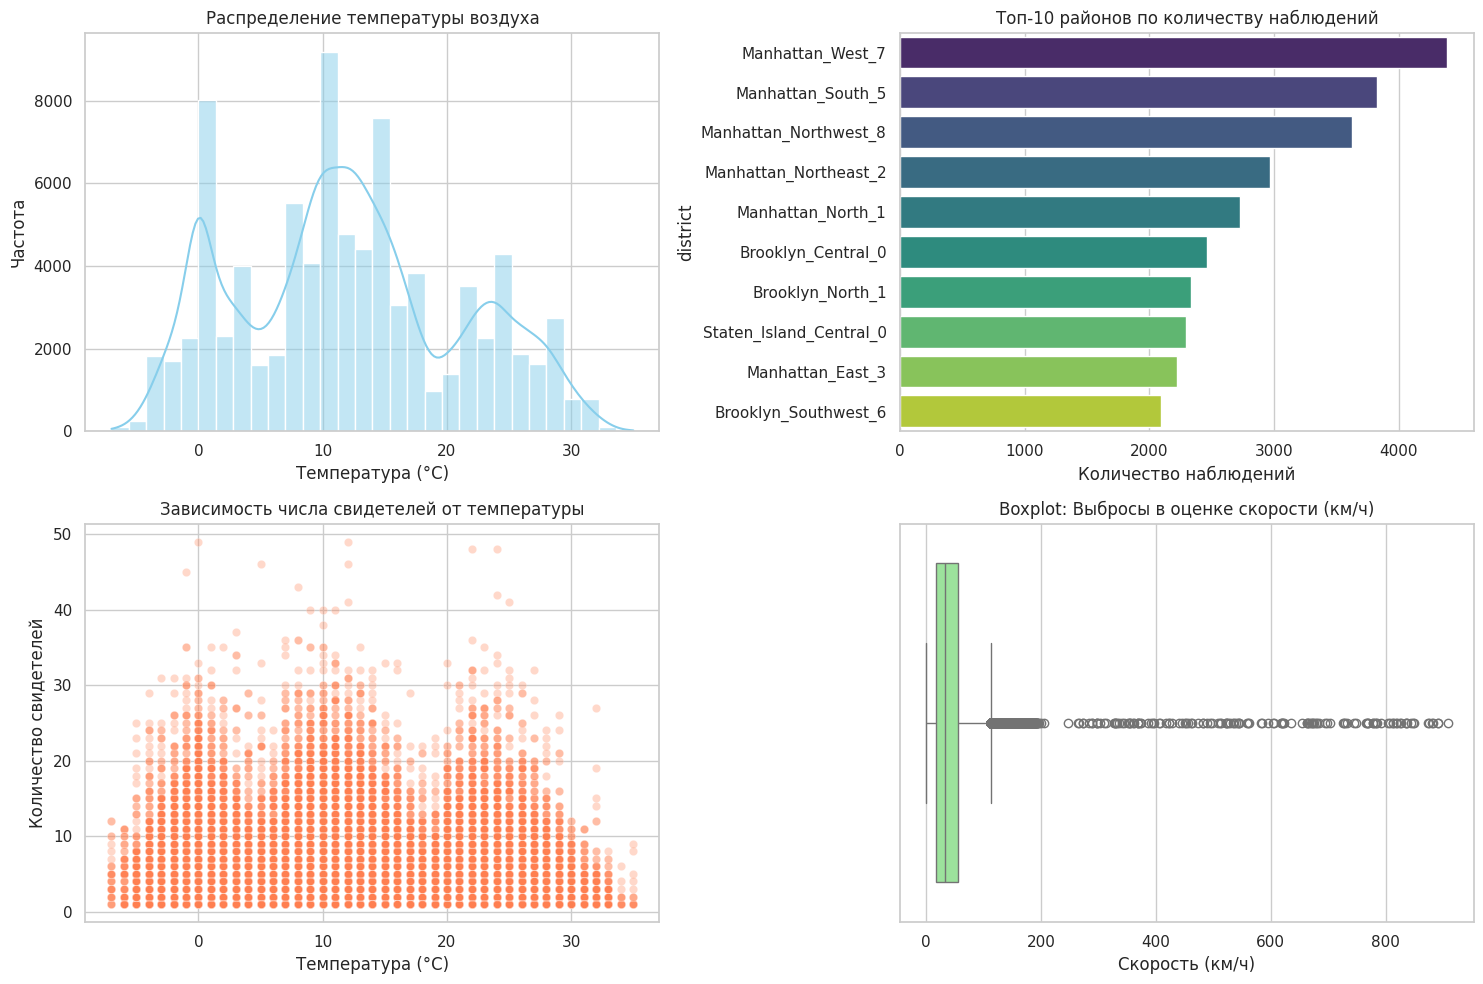

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля
sns.set(style="whitegrid")
plt.figure(figsize=(15, 10))

# 1. Гистограмма распределения температуры
plt.subplot(2, 2, 1)
sns.histplot(df['temperature_c'], bins=30, kde=True, color='skyblue')
plt.title('Распределение температуры воздуха')
plt.xlabel('Температура (°C)')
plt.ylabel('Частота')

# 2. Bar chart по районам (топ-10)
plt.subplot(2, 2, 2)
top_districts = df['district'].value_counts().head(10)
sns.barplot(x=top_districts.values, y=top_districts.index, hue=top_districts.index, palette='viridis', legend=False)
plt.title('Топ-10 районов по количеству наблюдений')
plt.xlabel('Количество наблюдений')

# 3. Scatterplot: Температура vs Количество свидетелей
plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x='temperature_c', y='witness_count', alpha=0.3, color='coral')
plt.title('Зависимость числа свидетелей от температуры')
plt.xlabel('Температура (°C)')
plt.ylabel('Количество свидетелей')

# 4. Boxplot для поиска выбросов в скорости
plt.subplot(2, 2, 4)
sns.boxplot(x=df['estimated_speed_kmh'], color='lightgreen')
plt.title('Boxplot: Выбросы в оценке скорости (км/ч)')
plt.xlabel('Скорость (км/ч)')

plt.tight_layout()
plt.show()

### 4.1. Комментарии к визуализациям

1.  **Распределение температуры:** График показывает, что большинство наблюдений происходит при температуре от 5°C до 20°C. Распределение близко к нормальному, но есть небольшой "хвост" в сторону низких температур.
2.  **Топ-10 районов:** Наибольшее количество наблюдений зафиксировано в районах Manhattan (особенно West, South, Northwest) и Brooklyn. Это может говорить о большей плотности населения или активности героя в центре города.
3.  **Температура vs Свидетели:** Явной линейной зависимости не видно. Однако можно заметить, что при экстремальных температурах (очень холодно или очень жарко) количество свидетелей может быть меньше. Требуется дополнительный анализ.
4.  **Boxplot скорости:** График наглядно демонстрирует выбросы. Большая часть значений находится в диапазоне до 80 км/ч, но есть точки, выходящие далеко за пределы "усов" (аномалии до 900 км/ч). Эти данные требуют очистки.